VISUALIZZAZIONE 3D ELETTRODI SEEG

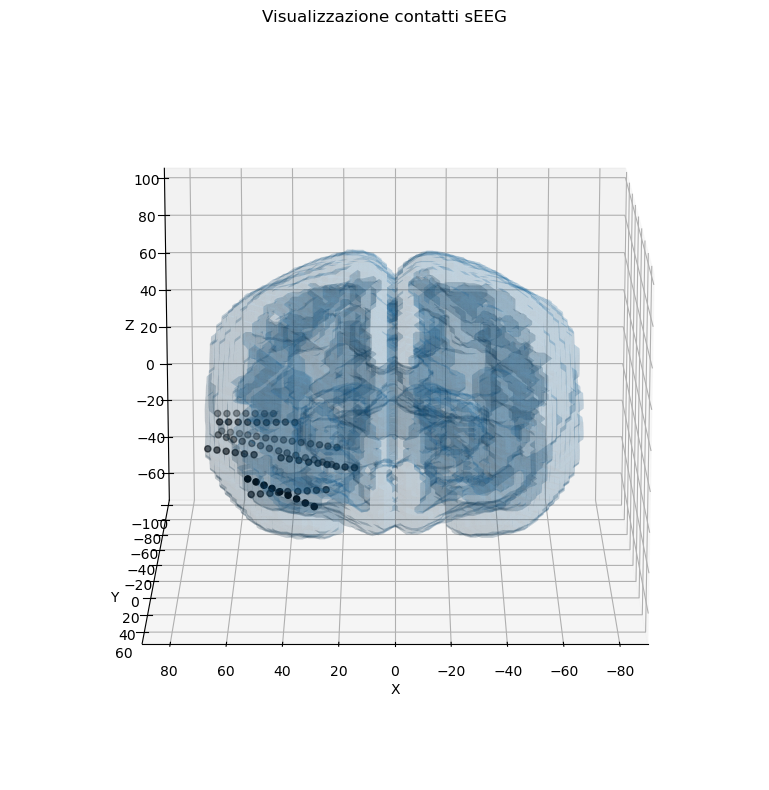

In [4]:
# LIBRERIE
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import scipy.io as sio
from skimage import measure
from pathlib import Path


try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    # Notebook / VS Code Interactive
    try:
        from IPython import get_ipython
        ip = get_ipython()
        # current working dir of the kernel/session
        ROOT = Path(ip.run_line_magic('pwd', ''))
    except Exception:
        ROOT = Path.cwd()

BASE = ROOT / "NCT_analysis\data"       # percorso alla cartella data del progetto

B0_TXT    = BASE / "centroidsB0_850ROIs.txt"
EPI_TXT   = BASE / "centroidsEPI_850ROIs.txt"
MNI_XLSX  = BASE / "centroidsMNI2mm_850ROIs.xlsx"
SEEG_MONO = BASE / "sEEG_3D_contacts_locs.mat"
SEEG_BI   = BASE / "sEEG_3D_BIPOLARcontacts_locs.mat"
T1_PATH = BASE / "Sheafer800_TianS3.nii"


# --- carica elettrodi dal .mat (come già fai) ---
mat = sio.loadmat(SEEG_BI, squeeze_me=True, struct_as_record=False)
A = mat["sEEG_3D_BIPOLARcontacts_locs"]      # (N,4) object: [id, x, y, z]
labels = A[:,0].astype(str)
elec = A[:,1:4].astype(float)               # Nx3

# --- carica T1 ---
img = nib.load(T1_PATH)
vol = img.get_fdata()
aff = img.affine

# --- estrai una superficie "testa" con una soglia robusta ---
# (percentile alto per prendere tessuti più densi; puoi cambiare 70-85)
thr = np.percentile(vol[vol > 0], 80)
mask = vol > 0

# marching cubes in coordinate voxel
verts_ijk, faces, _, _ = measure.marching_cubes(mask.astype(np.uint8), level=0.5)

# porta vertici in coordinate mondo (mm)
verts_xyz = nib.affines.apply_affine(aff, verts_ijk)

# --- plot statico ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(verts_xyz[:,0], verts_xyz[:,1], verts_xyz[:,2],
                triangles=faces, linewidth=0.0, antialiased=True, alpha=0.12)

ax.scatter(elec[:,0], elec[:,1], elec[:,2], s=20, c="k")
ax.set_title("Visualizzazione contatti sEEG")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.view_init(elev=15, azim=90)

# axis equal approx
mins = np.minimum(verts_xyz.min(0), elec.min(0))
maxs = np.maximum(verts_xyz.max(0), elec.max(0))
center = (mins + maxs) / 2
radius = (maxs - mins).max() / 2
ax.set_xlim(center[0]-radius, center[0]+radius)
ax.set_ylim(center[1]-radius, center[1]+radius)
ax.set_zlim(center[2]-radius, center[2]+radius)

plt.tight_layout()
plt.savefig("seeg_on_head_from_T1.png", dpi=200)
plt.show()